# Imports

In [1]:
%pip install catboost lightgbm optuna holidays

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 19.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, TimeSeriesSplit, cross_val_predict, cross_val_score, cross_validate
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer

from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

import optuna
from typing import Any
import warnings

import holidays

In [3]:
import plotly.io as pio
pio.renderers.default = "vscode"

# Global Vars

In [4]:
TARGET = "num_sold"
N_SPLITS = 5
SEED = 42
eps = 1e-5

def check_environment():
    try:
        import google.colab
        env = "colab"
    except ImportError:
        env = "local"
    return env

ENVIRONMENT = check_environment()

non_relevant_columns = ['id', 'source']

# ordinal_maps = {
#     "gender" : {"male":0, "female":1, "other":2},
#     "internet_access" : {"no":0, "yes":1},
#     "sleep_quality" : {"poor":0, "average":1, "good":2},
#     "facility_rating" : {"low":0, "medium":1, "high":2},
#     "exam_difficulty" : {"easy":0, "moderate":1, "hard":2},
#     "course" : {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#     "study_method" : {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
# }

original_categorical_cols = ['country', 'store', 'product']


# Load Data

In [8]:
def load_data(option: str="local"):
  '''
  returns train_df, test_df, df

  '''
  if option == "local":
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

  elif option == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    train_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Sticker Sales Forecast/train.csv')
    test_df = pd.read_csv('/content/drive/MyDrive/Kaggle Practice/Sticker Sales Forecast/test.csv')

  train_df['source'] = 'train'
  test_df['source'] = 'test'
  train_df['date'] =  pd.to_datetime(train_df['date'])
  test_df['date'] =  pd.to_datetime(test_df['date'])
  df = pd.concat([train_df, test_df], ignore_index=True)

  return train_df, test_df, df

# Data Splitter

In [6]:
def data_spliter(df: pd.DataFrame, additional_drop_columns: list = []) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame]:
    '''
    return: X_train, y_train, submission_df

    '''
    train_dataset = df[df['source'] == 'train'].drop(columns=non_relevant_columns + additional_drop_columns)
    submission_dataset = df[df['source'] == 'test'].drop(columns=['source', TARGET] + additional_drop_columns)

    X_train = train_dataset.drop(columns=[TARGET])
    y_train = train_dataset[TARGET]

    return X_train, y_train, submission_dataset

# EDA

In [9]:
df_train, df_test, df = load_data(option=ENVIRONMENT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Info / describe / etc.

In [10]:
df.head()

,id,date,country,store,product,num_sold,source
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN,train
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0,train
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,train
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0,train
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,train


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328680 entries, 0 to 328679
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        328680 non-null  int64         
 1   date      328680 non-null  datetime64[ns]
 2   country   328680 non-null  object        
 3   store     328680 non-null  object        
 4   product   328680 non-null  object        
 5   num_sold  221259 non-null  float64       
 6   source    328680 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 17.6+ MB


In [12]:
df.describe()

,id,date,num_sold
count,328680.000000,328680,221259.000000
mean,164339.500000,2014-12-31 12:00:00,752.527382
min,0.000000,2010-01-01 00:00:00,5.000000
25%,82169.750000,2012-07-01 18:00:00,219.000000
50%,164339.500000,2014-12-31 12:00:00,605.000000
75%,246509.250000,2017-07-01 06:00:00,1114.000000
max,328679.000000,2019-12-31 00:00:00,5939.000000
std,94881.887576,NaN,690.165445


In [13]:
df.isna().sum()

,0
id,0
date,0
country,0
store,0
product,0
num_sold,107421
source,0


## Test vs Train date

<Axes: xlabel='date', ylabel='Count'>

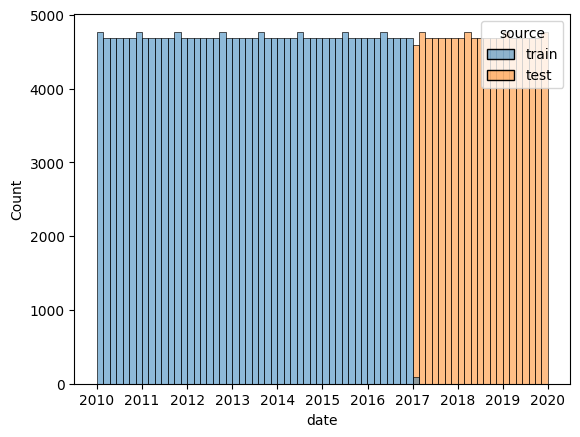

In [14]:
sns.histplot(df, x='date', hue='source')

## Num Sold overtime

In [15]:
df['date'].dt.year

,date
0,2010
1,2010
2,2010
3,2010
4,2010
...,...
328675,2019
328676,2019
328677,2019
328678,2019


<Axes: xlabel='num_sold', ylabel='Count'>

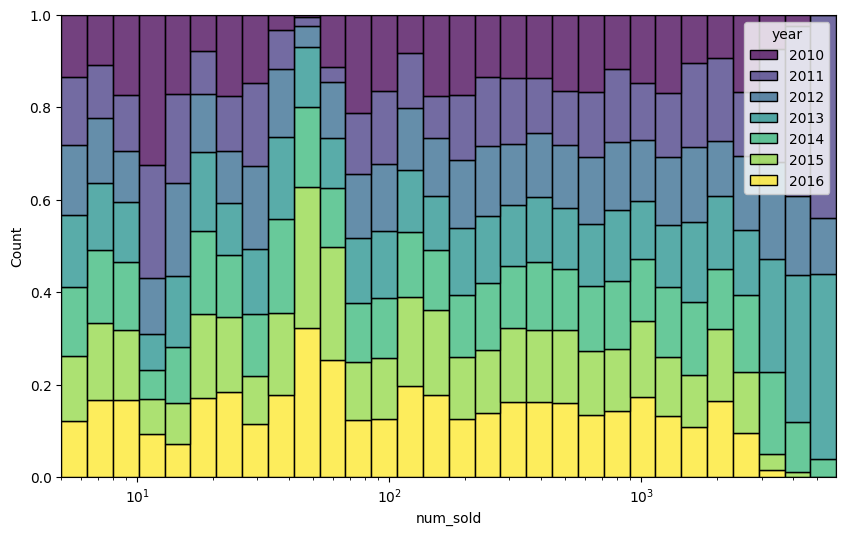

In [16]:
plt.figure(figsize=(10,6))
hist_data = df_train.copy()
hist_data['year'] = hist_data['date'].dt.year
sns.histplot(
    data=hist_data,
    x='num_sold',
    hue='year',
    bins=30,
    log_scale=True,
    palette='viridis',
    multiple='fill',
)

<Axes: xlabel='date', ylabel='num_sold'>

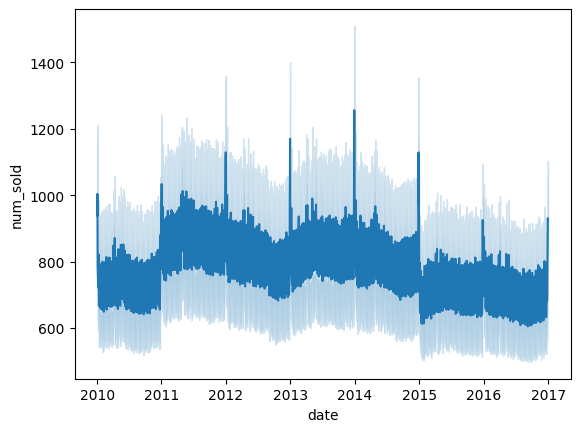

In [18]:
sns.lineplot(data=df, x='date', y='num_sold')

<Axes: xlabel='date', ylabel='num_sold'>

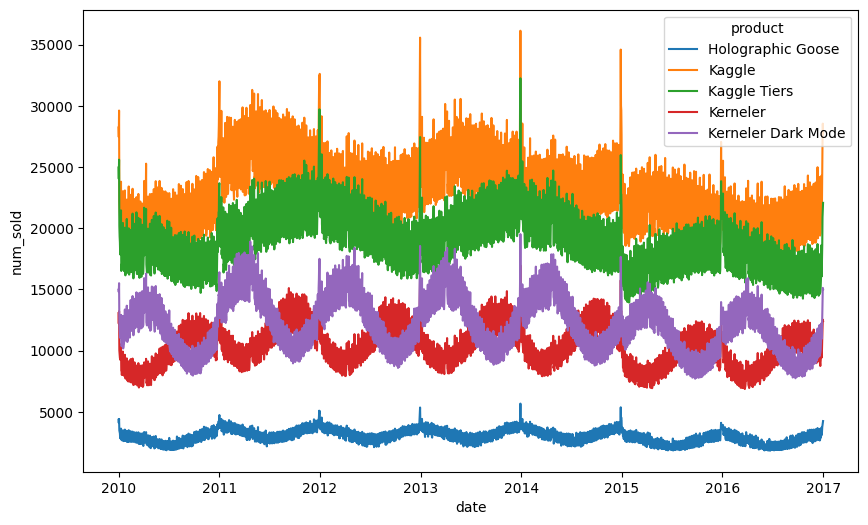

In [19]:
plt.figure(figsize=(10,6))
grouped = df_train.groupby([pd.Grouper(key='date', freq='D'), 'product'])['num_sold'].sum().reset_index()
sns.lineplot(data=grouped, x='date', y='num_sold', hue='product')

<Axes: xlabel='date', ylabel='num_sold'>

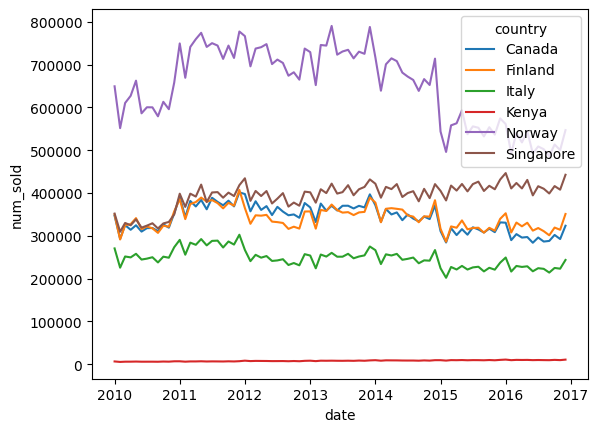

In [20]:
grouped = df_train.groupby([pd.Grouper(key='date', freq='MS'), 'country'])['num_sold'].sum().reset_index()
sns.lineplot(data=grouped, x='date', y='num_sold', hue='country')

In [21]:
df['product'].unique()

array(['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler',
       'Kerneler Dark Mode'], dtype=object)

## Country

In [22]:
df['country'].unique()

array(['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore'],
      dtype=object)

In [23]:
holidays.KE( years=range(2020, 2027))

{datetime.date(2020, 1, 1): "New Year's Day", datetime.date(2020, 4, 10): 'Good Friday', datetime.date(2020, 4, 13): 'Easter Monday', datetime.date(2020, 5, 1): 'Labor Day', datetime.date(2020, 6, 1): 'Madaraka Day', datetime.date(2020, 10, 10): 'Moi Day', datetime.date(2020, 10, 20): 'Mashujaa Day', datetime.date(2020, 12, 12): 'Jamhuri Day', datetime.date(2020, 12, 25): 'Christmas Day', datetime.date(2020, 12, 26): 'Boxing Day', datetime.date(2020, 5, 25): 'Eid al-Fitr', datetime.date(2020, 2, 11): 'President Moi Memorial Day', datetime.date(2021, 1, 1): "New Year's Day", datetime.date(2021, 4, 2): 'Good Friday', datetime.date(2021, 4, 5): 'Easter Monday', datetime.date(2021, 5, 1): 'Labor Day', datetime.date(2021, 6, 1): 'Madaraka Day', datetime.date(2021, 10, 10): 'Utamaduni Day', datetime.date(2021, 10, 20): 'Mashujaa Day', datetime.date(2021, 12, 12): 'Jamhuri Day', datetime.date(2021, 12, 25): 'Christmas Day', datetime.date(2021, 12, 26): 'Boxing Day', datetime.date(2021, 5, 14)

# Feature engineering

In [29]:
def cyclical(df, col, period):
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / period)

cyclical(df, 'month', 12)
cyclical(df, 'dayofweek', 7)
cyclical(df, 'hour', 24)

KeyError: 'month'

In [ ]:
def feature_engineering(fdf: pd.DataFrame) -> pd.DataFrame:
    '''
    return: df with new features

    '''
    df = fdf.copy()
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['quarter'] = df['date'].dt.quarter
    df['day_of_week'] = df['date'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    # Add holiday feature for Kenya

    return df

<Axes: title={'center': 'Daily Sticker Sales'}, xlabel='Date', ylabel='Number of Stickers Sold'>

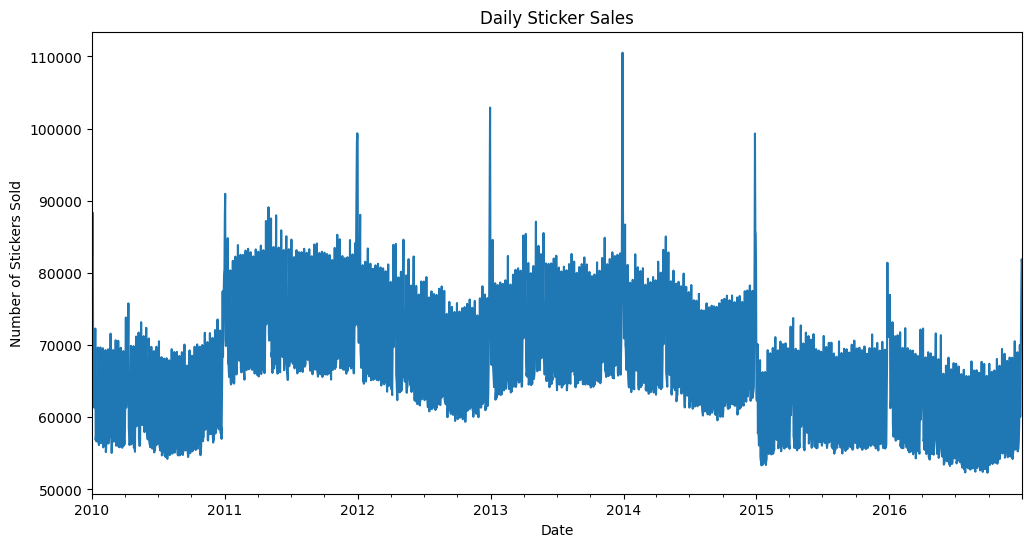

In [35]:
df_train.groupby('date')['num_sold'].sum().plot(figsize=(12, 6), title='Daily Sticker Sales', xlabel='Date', ylabel='Number of Stickers Sold')

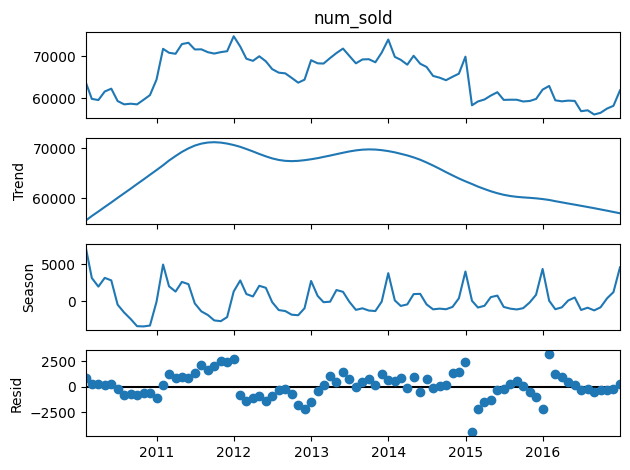

In [45]:
from statsmodels.tsa.seasonal import STL
import pandas as pd

df_stats = df_train.copy()
df_stats['date'] = pd.to_datetime(df_stats['date'])

s = df_stats.groupby('date')['num_sold'].sum()   # one value per day
m = s.resample('ME').mean()                       # average daily sales per month

res = STL(m, period=12).fit()                     # yearly pattern
res.plot();

# Ridge

In [28]:
df.head()

,id,date,country,store,product,num_sold,source
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN,train
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0,train
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0,train
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0,train
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0,train


In [ ]:
X, y, submission_df = data_spliter(df)